### CAPSTONE PROJECT

#### Step 1: Problem Understanding & Framing

##### 1.1 Problem Statement
> The current educational landscape is characterized by a significant "intervention lag." Despite the wealth of digital student data available, institutions primarily rely on end-of-term results to identify academic failure. This reactive approach results in high attrition rates, leading to substantial institutional revenue loss and diminished student lifetime outcomes. There is a critical need for a reusable, proactive predictive framework that identifies at-risk students while there is still time for meaningful intervention.

##### 1.2 Business & Data Science Problem Framing
> A. The Business Perspective (Institutional Impact)
> * Business Problem: How can an institution optimize its student support services to improve retention rates and protect tuition revenue?
> * Decision Context: Faculty and counselors have limited time; they require a prioritized list of students ranked by "Probability of Attrition."
> * Key Performance Indicators (KPIs): 1.  Retention Rate Uplift: The percentage increase in students remaining enrolled year-over-year.2.  Intervention Lead Time: The number of weeks prior to final exams that a risk flag is generated.3.  Cost-Benefit Ratio: The financial gain from retained tuition versus the cost of intervention and model maintenance.


> B. The Data Science Perspective (Technical Definition)
> * Learning Task: Supervised Binary Classification.
> * Target Variable ($y$): $$y = \begin{cases} 1 & \text{if student drops out} \\ 0 & \text{if student persists} \end{cases}$$
> * Feature Space ($X$): A set of multi-modal features including demographic variables, academic performance trends (time-series), and digital engagement metrics (LMS logs).
> * Optimization Function: Given the high cost of missing a student in need, the model will be optimized to maximize the Area Under the Precision-Recall Curve (AUPRC) and Recall ($Sensitivity$) rather than simple accuracy.

##### 1.3 Success Metrics

> A. Statistical Evaluation Metrics (Data Science) <br><br>
> Given the inherent class imbalance in student retention data—where dropouts typically represent a minority of the population—traditional accuracy is an insufficient measure of success. The following metrics will be prioritized:
> * Recall (Sensitivity): Calculated as $\frac{TP}{TP + FN}$. This is the primary technical metric, as the cost of a "False Negative" (failing to identify a student who eventually drops out) is significantly higher than a "False Positive."
> * Precision: Calculated as $\frac{TP}{TP + FP}$. This ensures the model maintains credibility with faculty by minimizing "False Alarms."
> * Area Under the Precision-Recall Curve (AUPRC): Unlike the standard ROC curve, AUPRC provides a more robust assessment of model performance in imbalanced datasets by focusing on the minority class (Dropouts).
> * F1-Score: The harmonic mean of Precision and Recall, providing a single balanced metric for model comparison during the hyperparameter tuning phase.

> B. Institutional Business KPIs
> * Retention Uplift: The primary measure of success, calculated as the year-over-year percentage increase in student enrollment stability compared to the pre-AI baseline.
> * Intervention Lead Time: A measure of proactivity that tracks the number of weeks between the initial "At-Risk" flag and the student's projected withdrawal date; the goal is to provide a minimum 4-week window for counseling.
> * Precision-at-K: A focus on operational efficiency that measures the accuracy of the model specifically within the top $K$ (e.g., top 50) highest-risk students to ensure counselor time is not wasted on false alarms.
> * Cost Avoidance: The financial impact of the model, determined by calculating the total tuition revenue preserved through successful interventions for students flagged as high-risk.

#### Step 2: Data Collection & Understanding

##### 2.1. About the Dataset
> This dataset originates from a Portuguese higher education institution and was developed as part of a national project aiming to combat student dropout and academic failure in universities. It brings together rich information from 4,424 undergraduate students across 8 degree programs, such as Agronomy, Design, Education, Nursing, Journalism, Management, Social Service, and Technologies.
>
> The dataset was downloaded fron kaggel: [Student Dropout & Success Prediction Dataset](https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success/data). The dataset originally created under the SATDAP - Capacitação da Administração Pública project funded by POCI-05-5762-FSE-000191 (Portugal) and is also available through the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success).
>



##### 2.2 Summarise feature types, missing values, outliers, etc.

In [263]:
# Loading the dataset
import pandas as pd
data = pd.read_csv('./students_dropout_academic_success.csv')
data.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [264]:
#map target column such that 0 = Dropout, 1 = Graduate, 2 = Enrolled
data['target'] = data['target'].map({'Dropout': 0, 'Graduate': 1, 'Enrolled': 2})
            

In [265]:
data['target'].head()

0    0
1    1
2    0
3    1
4    1
Name: target, dtype: int64

In [266]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

##### 2.3 Data Dictionary
# Predict Students' Dropout and Academic Success – Full Variable Table

| **Item#** | **Feature Name**                                | **Description**                          | **Type**     | **Allowed Values** |
|-----------|-------------------------------------------------|------------------------------------------|--------------|---------------------|
| 1  | Marital Status                                | Student’s marital status                 | categorical  | 1 = Single<br>2 = Married<br>3 = Widower<br>4 = Divorced<br>5 = Facto union<br>6 = Legally separated |
| 2  | Application mode                              | Mode of application                      | categorical  | 1 = 1st phase – general contingent<br>2 = Ordinance No. 612/93<br>5 = 1st phase – special contingent (Azores Island)<br>7 = Holders of other higher courses<br>10 = Ordinance No. 854-B/99<br>15 = International student (bachelor)<br>16 = 1st phase – special contingent (Madeira Island)<br>17 = 2nd phase – general contingent<br>18 = 3rd phase – general contingent<br>26 = Ordinance No. 533-A/99, (item b2) (Different Plan)<br>27 = Ordinance No. 533-A/99, item b3 (Other Institution)<br>39 = Over 23 years old<br>42 = Transfer<br>43 = Change of course<br>44 = Technological specialization diploma holders<br>51 = Change of institution/course<br>53 = Short cycle diploma holders<br>57 = Change of institution/course (International) |
| 3  | Application order                             | Order of preference                      | numerical    | min = 1, max = 9 |
| 4  | Course                                        | Degree program                           | categorical  | 33 = Biofuel Production Technologies<br>171 = Animation and Multimedia Design<br>8014 = Social Service (evening attendance)<br>9003 = Agronomy<br>9070 = Communication Design<br>9085 = Veterinary Nursing<br>9119 = Informatics Engineering<br>9130 = Equinculture<br>9147 = Management<br>9238 = Social Service<br>9254 = Tourism<br>9500 = Nursing<br>9556 = Oral Hygiene<br>9670 = Advertising and Marketing Management<br>9773 = Journalism and Communication<br>9853 = Basic Education<br>9991 = Management (evening attendance) |
| 5  | Daytime/evening attendance                    | Attendance type                          | categorical  | 1 = Daytime<br>0 = Evening |
| 6  | Previous qualification                        | Highest qualification before enrollment  | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 7  | Previous qualification (grade)                | Grade obtained in previous qualification | numerical    | min = 0, max = 200 |
| 8  | Nacionality                                   | Student’s nationality                    | categorical  | 1 - Portuguese<br>2 - German<br>6 - Spanish<br>11 - Italian<br>13 - Dutch<br>14 - English<br>17 - Lithuanian<br>21 - Angolan<br>22 - Cape Verdean<br>24 - Guinean<br>25 - Mozambican<br>26 - Santomean<br>32 - Turkish<br>41 - Brazilian<br>62 - Romanian<br>100 - Moldova (Republic of)<br>101 - Mexican<br>103 - Ukrainian<br>105 - Russian<br>108 - Cuban<br>109 - Colombian |
| 9  | Mother's qualification                        | Mother’s highest qualification           | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 10 | Father's qualification                        | Father’s highest qualification           | categorical  | 1 = Secondary education<br>2 = Higher education – bachelor's degree<br>3 = Higher education – degree<br>4 = Higher education – master's<br>5 = Higher education – doctorate<br>6 = Frequency of higher education<br>9 = 12th year of schooling – not completed<br>10 = 11th year of schooling – not completed<br>12 = Other – 11th year of schooling<br>14 = 10th year of schooling<br>15 = 10th year of schooling – not completed<br>19 = Basic education 3rd cycle (9th/10th/11th year) or equivalent<br>38 = Basic education 2nd cycle (6th/7th/8th year) or equivalent<br>39 = Technological specialization course<br>40 = Higher education – degree (1st cycle)<br>42 = Professional higher technical course<br>43 = Higher education – master (2nd cycle) |
| 11 | Mother's occupation                           | Mother’s occupation                      | categorical  | 0 = Student<br>1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers<br>2 = Specialists in Intellectual and Scientific Activities<br>3 = Intermediate Level Technicians and Professions<br>4 = Administrative staff<br>5 = Personal Services, Security and Safety Workers and Sellers<br>6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry<br>7 = Skilled Workers in Industry, Construction and Craftsmen<br>8 = Installation and Machine Operators and Assembly Workers<br>9 = Unskilled Workers<br>10 = Armed Forces Professions<br>90 = Other Situation<br>99 = (blank)<br>122 = Health professionals<br>123 = Teachers<br>125 = Specialists in information and communication technologies (ICT)<br>131 = Intermediate level science and engineering technicians and professions<br>132 = Technicians and professionals, of intermediate level of health<br>134 = Intermediate level technicians from legal, social, sports, cultural and similar services<br>141 = Office workers, secretaries in general and data processing operators<br>143 = Data, accounting, statistical, financial services and registry-related operators<br>144 = Other administrative support staff<br>151 = Personal service workers<br>152 = Sellers<br>153 = Personal care workers and the like<br>171 = Skilled construction workers and the like, except electricians<br>173 = Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like<br>175 = Workers in food processing, woodworking, clothing and other industries and crafts<br>191 = Cleaning workers<br>192 = Unskilled workers in agriculture, animal production, fisheries and forestry<br>193 = Unskilled workers in extractive industry, construction, manufacturing and transport<br>194 = Meal preparation assistants |
| 12 | Father's occupation                           | Father’s occupation                      | categorical  | 0 = Student<br>1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers<br>2 = Specialists in Intellectual and Scientific Activities<br>3 = Intermediate Level Technicians and Professions<br>4 = Administrative staff<br>5 = Personal Services, Security and Safety Workers and Sellers<br>6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry<br>7 = Skilled Workers in Industry, Construction and Craftsmen<br>8 = Installation and Machine Operators and Assembly Workers<br>9 = Unskilled Workers<br>10 = Armed Forces Professions<br>90 = Other Situation<br>99 = (blank)<br>122 = Health professionals<br>123 = Teachers<br>125 = Specialists in information and communication technologies (ICT)<br>131 = Intermediate level science and engineering technicians and professions<br>132 = Technicians and professionals, of intermediate level of health<br>134 = Intermediate level technicians from legal, social, sports, cultural and similar services<br>141 = Office workers, secretaries in general and data processing operators<br>143 = Data, accounting, statistical, financial services and registry-related operators<br>144 = Other administrative support staff<br>151 = Personal service workers<br>152 = Sellers<br>153 = Personal care workers and the like<br>171 = Skilled construction workers and the like, except electricians<br>173 = Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like<br>175 = Workers in food processing, woodworking, clothing and other industries and crafts<br>191 = Cleaning workers<br>192 = Unskilled workers in agriculture, animal production, fisheries and forestry<br>193 = Unskilled workers in extractive industry, construction, manufacturing and transport<br>194 = Meal preparation assistants<br>195 - Street vendors (except food) and street service providers |
| 13 | Admission grade                               | Admission grade at enrollment            | numerical    | min = 0, max = 200 |
| 14 | Displaced                                     | Refugee/displaced status                 | binary  | 1 = Yes<br>0 = No |
| 15 | Educational special needs                     | Special educational needs                | binary  | 1 = Yes<br>0 = No |
| 16 | Debtor                                        | Outstanding debts                        | binary  | 1 = Yes<br>0 = No |
| 17 | Tuition fees up to date                       | Tuition fees paid up to date             | binary | 1 = Yes<br>0 = No |
| 18 | Gender                                        | Gender                                   | binary | 1 = Male<br>0 = Female |
| 19 | Scholarship holder                            | Scholarship status                       | binary  | 1 = Yes<br>0 = No |
| 20 | Age at enrollment                             | Age when enrolled                        | numerical    | min = 0, max = 70 |
| 21 | International                                 | International student                    | binary  | 1 = Yes<br>0 = No |
| 22 | Curricular units 1st sem (credited)           | Credited units (1st semester)            | numerical    | min = 0, max = 20 |
| 23 | Curricular units 1st sem (enrolled)           | Enrolled units (1st semester)            | numerical    | min = 0, max = 20 |
| 24 | Curricular units 1st sem (evaluations)        | Evaluations (1st semester)               | numerical    | min = 0, max = 20 |
| 25 | Curricular units 1st sem (approved)           | Approved units (1st semester)            | numerical    | min = 0, max = 20 |
| 26 | Curricular units 1st sem (grade)              | Average grade (1st semester)             | numerical    | min = 0, max = 20 |
| 27 | Curricular units 1st sem (without evaluations)| Units without evaluation (1st semester)  | numerical    | min = 0, max = 20 |
| 28 | Curricular units 2nd sem (credited)           | Credited units (2nd semester)            | numerical    | min = 0, max = 20 |
| 29 | Curricular units 2nd sem (enrolled)           | Enrolled units (2nd semester)            | numerical    | min = 0, max = 20 |
| 30 | Curricular units 2nd sem (evaluations)        | Evaluations (2nd semester)               | numerical    | min = 0, max = 20 |
| 31 | Curricular units 2nd sem (approved)           | Approved units (2nd semester)            | numerical    | min = 0, max = 20 |
| 32 | Curricular units 2nd sem (grade)              | Average grade (2nd semester)             | numerical    | min = 0, max = 20 |
| 33 | Curricular units 2nd sem (without evaluations)| Units without evaluation (2nd semester)  | numerical    | min = 0, max = 20 |
| 34 | Unemployment rate                             | National unemployment rate (%)           | numerical    | min = 0.0, max = 100.0 |
| 35 | Inflation rate                                | National inflation rate (%)              | numerical    | min = -100.0, max = 100.0 |
| 36 | GDP                                           | National GDP                             | numerical    | min = 0.0, max = 1e13 |
| 37 | target                                        | Final student status                     | categorical  | 0 = Dropout<br>1 = Graduate<br>2 = Enrolled |




In [267]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [268]:
dataset_dictionary = [
    {
        "feature_name": "Marital Status",
        "description": "Student’s marital status",
        "type": "categorical",
        "allowed_values": {
            "1": "Single", "2": "Married", "3": "Widower", 
            "4": "Divorced", "5": "Facto union", "6": "Legally separated"
        }
    },
    {
        "feature_name": "Application mode",
        "description": "Mode of application",
        "type": "categorical",
        "allowed_values": {
            "1": "1st phase – general contingent", "2": "Ordinance No. 612/93", 
            "5": "1st phase – special contingent (Azores Island)", "7": "Holders of other higher courses",
            "10": "Ordinance No. 854-B/99", "15": "International student (bachelor)",
            "16": "1st phase – special contingent (Madeira Island)", "17": "2nd phase – general contingent",
            "18": "3rd phase – general contingent", "26": "Ordinance No. 533-A/99, (item b2) (Different Plan)",
            "27": "Ordinance No. 533-A/99, item b3 (Other Institution)", "39": "Over 23 years old",
            "42": "Transfer", "43": "Change of course", "44": "Technological specialization diploma holders",
            "51": "Change of institution/course", "53": "Short cycle diploma holders",
            "57": "Change of institution/course (International)"
        }
    },
    {
        "feature_name": "Application order",
        "description": "Order of preference",
        "type": "numerical",
        "allowed_values": {"min": 1, "max": 9}
    },
    {
        "feature_name": "Course",
        "description": "Degree program",
        "type": "categorical",
        "allowed_values": {
            "33": "Biofuel Production Technologies", "171": "Animation and Multimedia Design", 
            "8014": "Social Service (evening attendance)", "9003": "Agronomy",
            "9070": "Communication Design", "9085": "Veterinary Nursing", 
            "9119": "Informatics Engineering", "9130": "Equinculture", "9147": "Management",
            "9238": "Social Service", "9254": "Tourism", "9500": "Nursing", 
            "9556": "Oral Hygiene", "9670": "Advertising and Marketing Management",
            "9773": "Journalism and Communication", "9853": "Basic Education", 
            "9991": "Management (evening attendance)"
        }
    },
    {
        "feature_name": "Daytime/evening attendance",
        "description": "Attendance type",
        "type": "categorical",
        "allowed_values": {"1": "Daytime", "0": "Evening"}
    },
    {
        "feature_name": "Previous qualification",
        "description": "Highest qualification before enrollment",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree", 
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Previous qualification (grade)",
        "description": "Grade obtained in previous qualification",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 200}
    },
    {
        "feature_name": "Nacionality",
        "description": "Student’s nationality",
        "type": "categorical",
        "allowed_values": {
            "1": "Portuguese", "2": "German", "6": "Spanish", "11": "Italian", "13": "Dutch",
            "14": "English", "17": "Lithuanian", "21": "Angolan", "22": "Cape Verdean",
            "24": "Guinean", "25": "Mozambican", "26": "Santomean", "32": "Turkish",
            "41": "Brazilian", "62": "Romanian", "100": "Moldova", "101": "Mexican",
            "103": "Ukrainian", "105": "Russian", "108": "Cuban", "109": "Colombian"
        }
    },
    {
        "feature_name": "Mother's qualification",
        "description": "Mother’s highest qualification",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree", 
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Father's qualification",
        "description": "Father’s highest qualification",
        "type": "categorical",
        "allowed_values": {
            "1": "Secondary education", "2": "Higher education – bachelor's degree", 
            "3": "Higher education – degree", "4": "Higher education – master's",
            "5": "Higher education – doctorate", "6": "Frequency of higher education",
            "9": "12th year of schooling – not completed", "10": "11th year of schooling – not completed",
            "12": "Other – 11th year of schooling", "14": "10th year of schooling",
            "15": "10th year of schooling – not completed", "19": "Basic education 3rd cycle or equivalent",
            "38": "Basic education 2nd cycle or equivalent", "39": "Technological specialization course",
            "40": "Higher education – degree (1st cycle)", "42": "Professional higher technical course",
            "43": "Higher education – master (2nd cycle)"
        }
    },
    {
        "feature_name": "Mother's occupation",
        "description": "Mother’s occupation",
        "type": "categorical",
        "allowed_values": {
            "0": "Student", "1": "Representatives/Directors", "2": "Intellectual/Scientific Specialists",
            "3": "Intermediate Technicians", "4": "Administrative staff", "5": "Personal Services/Security",
            "6": "Farmers/Skilled Agriculture", "7": "Skilled Industry/Construction", 
            "8": "Installation/Machine Operators", "9": "Unskilled Workers", "10": "Armed Forces",
            "90": "Other Situation", "99": "blank", "122": "Health professionals", "123": "Teachers",
            "125": "ICT Specialists", "131": "Science/Engineering Technicians", 
            "132": "Health Technicians", "134": "Legal/Social/Culture Technicians", 
            "141": "Office/Data Operators", "143": "Financial/Registry Operators",
            "144": "Other admin support", "151": "Personal service", "152": "Sellers",
            "153": "Personal care", "171": "Skilled construction", "173": "Printing/Precision workers",
            "175": "Food/Wood/Clothing workers", "191": "Cleaning workers", 
            "192": "Unskilled Agriculture/Forestry", "193": "Unskilled Extractive/Transport",
            "194": "Meal preparation assistants"
        }
    },
    {
        "feature_name": "Father's occupation",
        "description": "Father’s occupation",
        "type": "categorical",
        "allowed_values": {
            "0": "Student", "1": "Representatives/Directors", "2": "Intellectual/Scientific Specialists",
            "3": "Intermediate Technicians", "4": "Administrative staff", "5": "Personal Services/Security",
            "6": "Farmers/Skilled Agriculture", "7": "Skilled Industry/Construction", 
            "8": "Installation/Machine Operators", "9": "Unskilled Workers", "10": "Armed Forces",
            "90": "Other Situation", "99": "blank", "122": "Health professionals", "123": "Teachers",
            "125": "ICT Specialists", "131": "Science/Engineering Technicians", 
            "132": "Health Technicians", "134": "Legal/Social/Culture Technicians", 
            "141": "Office/Data Operators", "143": "Financial/Registry Operators",
            "144": "Other admin support", "151": "Personal service", "152": "Sellers",
            "153": "Personal care", "171": "Skilled construction", "173": "Printing/Precision workers",
            "175": "Food/Wood/Clothing workers", "191": "Cleaning workers", 
            "192": "Unskilled Agriculture/Forestry", "193": "Unskilled Extractive/Transport",
            "194": "Meal preparation assistants"
        }
    },
    {
        "feature_name": "Admission grade",
        "description": "Admission grade at enrollment",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 200}
    },
    {
        "feature_name": "Displaced",
        "description": "Refugee/displaced status",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Educational special needs",
        "description": "Special educational needs",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Debtor",
        "description": "Outstanding debts",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Tuition fees up to date",
        "description": "Tuition fees paid up to date",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Gender",
        "description": "Gender",
        "type": "binary",
        "allowed_values": {"1": "Male", "0": "Female"}
    },
    {
        "feature_name": "Scholarship holder",
        "description": "Scholarship status",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Age at enrollment",
        "description": "Age when enrolled",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 70}
    },
    {
        "feature_name": "International",
        "description": "International student",
        "type": "binary",
        "allowed_values": {"1": "Yes", "0": "No"}
    },
    {
        "feature_name": "Curricular units 1st sem (credited)",
        "description": "Credited units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (enrolled)",
        "description": "Enrolled units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (evaluations)",
        "description": "Evaluations (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (approved)",
        "description": "Approved units (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (grade)",
        "description": "Average grade (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 1st sem (without evaluations)",
        "description": "Units without evaluation (1st semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (credited)",
        "description": "Credited units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (enrolled)",
        "description": "Enrolled units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (evaluations)",
        "description": "Evaluations (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (approved)",
        "description": "Approved units (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (grade)",
        "description": "Average grade (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Curricular units 2nd sem (without evaluations)",
        "description": "Units without evaluation (2nd semester)",
        "type": "numerical",
        "allowed_values": {"min": 0, "max": 20}
    },
    {
        "feature_name": "Unemployment rate",
        "description": "National unemployment rate (%)",
        "type": "numerical",
        "allowed_values": {"min": 0.0, "max": 100.0}
    },
    {
        "feature_name": "Inflation rate",
        "description": "National inflation rate (%)",
        "type": "numerical",
        "allowed_values": {"min": -100.0, "max": 100.0}
    },
    {
        "feature_name": "GDP",
        "description": "National GDP",
        "type": "numerical",
        "allowed_values": {"min": 0.0, "max": 1e13}
    },
    {
        "feature_name": "target",
        "description": "Final student status",
        "type": "categorical",
        "allowed_values": {"0": "Dropout", "1": "Graduate", "2": "Enrolled"}
    }
]

In [269]:
#compare the feature names with the dataset columns are the same (this is to check if any feature is missing or extra)
features = [f["feature_name"] for f in dataset_dictionary]
data_cols = list(data.columns)

print("len(dataset_dictionary):", len(features))
print("len(data.columns):", len(data_cols))


len(dataset_dictionary): 37
len(data.columns): 37


#### Step 3. Data Preprocessing, Applied EDA & Feature Engineering 

##### 3.1 Data Cleaning and Encoding
> Data is pre-cleaned from data source to verify see the printed info of the dataset below.

In [270]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

As we can see from the result all columns has 4424 non-null value and all have 0 null value.
All categorical and binary data also pre-encoded as well. 

##### 3.2 Exploratory Data Analysis

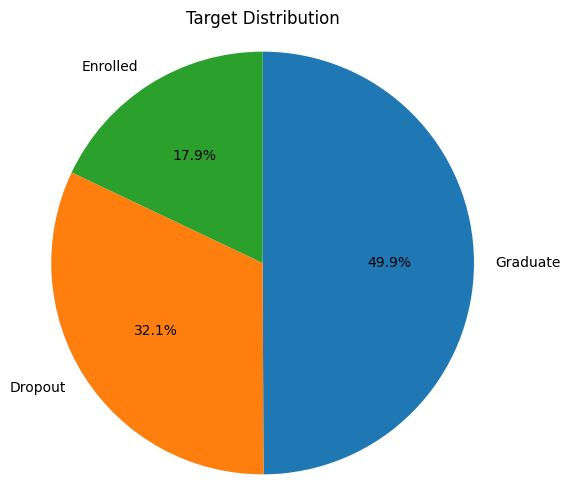

In [271]:
# Pie chart for the target column
import matplotlib.pyplot as plt

col_data = data['target']
counts = col_data.value_counts()
labels = counts.index.map({0: 'Dropout', 1: 'Graduate', 2: 'Enrolled'}).tolist()
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Target Distribution')
plt.axis('equal')
plt.show()

Since, for training the model we will remove student that are currently enrolled.

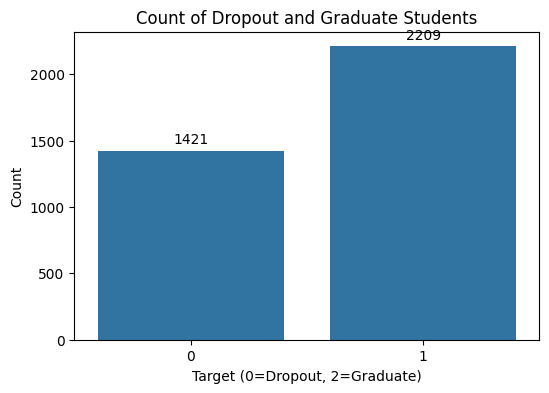

(3630, 37)

In [272]:
#Separate the enrolled students from dropouts and graduates
enrolled_data = data[data['target'] == 2]
dropout_graduate_data = data[data['target'] != 2]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=dropout_graduate_data)
plt.title('Count of Dropout and Graduate Students')
plt.xlabel('Target (0=Dropout, 2=Graduate)')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.show()

dropout_graduate_data.shape

The dropout and graduate students are relatively balance and can be used for training the model.

Next we do a correlation analysis between the target column and all other features.

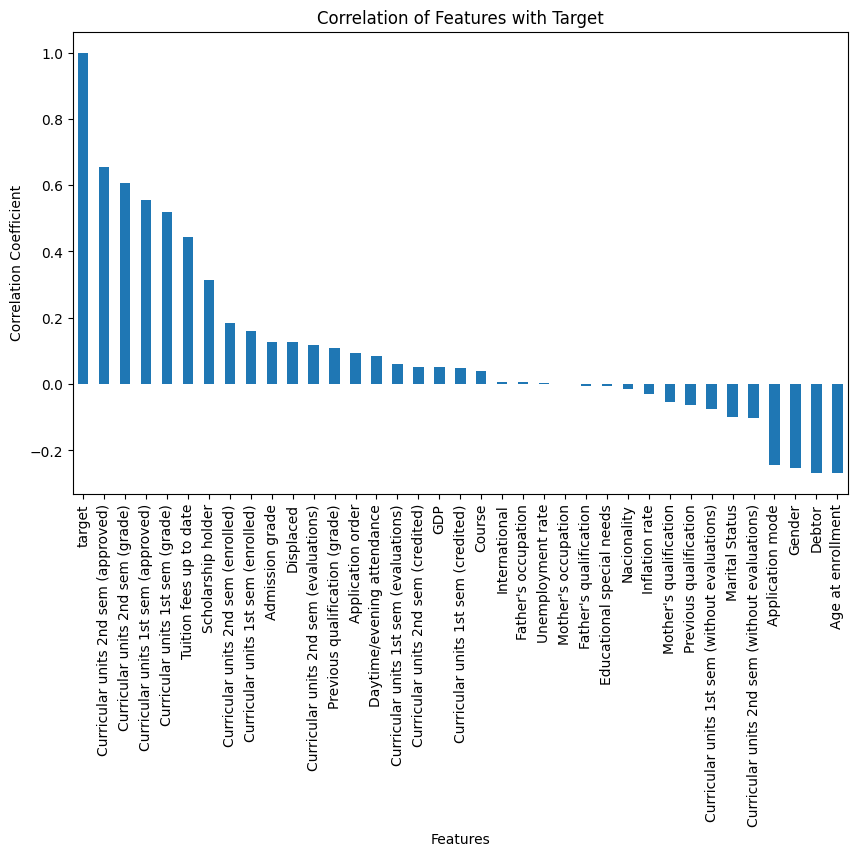

In [273]:
# correlation analysis between the target column and all other features and show it in a plot
correlation_matrix = dropout_graduate_data.corr()
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
target_correlation

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
target_correlation.plot(kind='bar')
plt.title('Correlation of Features with Target')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()



In [274]:
from sklearn.ensemble import RandomForestClassifier

# Train model
X = dropout_graduate_data.drop(columns=["target"])
y = dropout_graduate_data["target"]
model = RandomForestClassifier().fit(X, y)

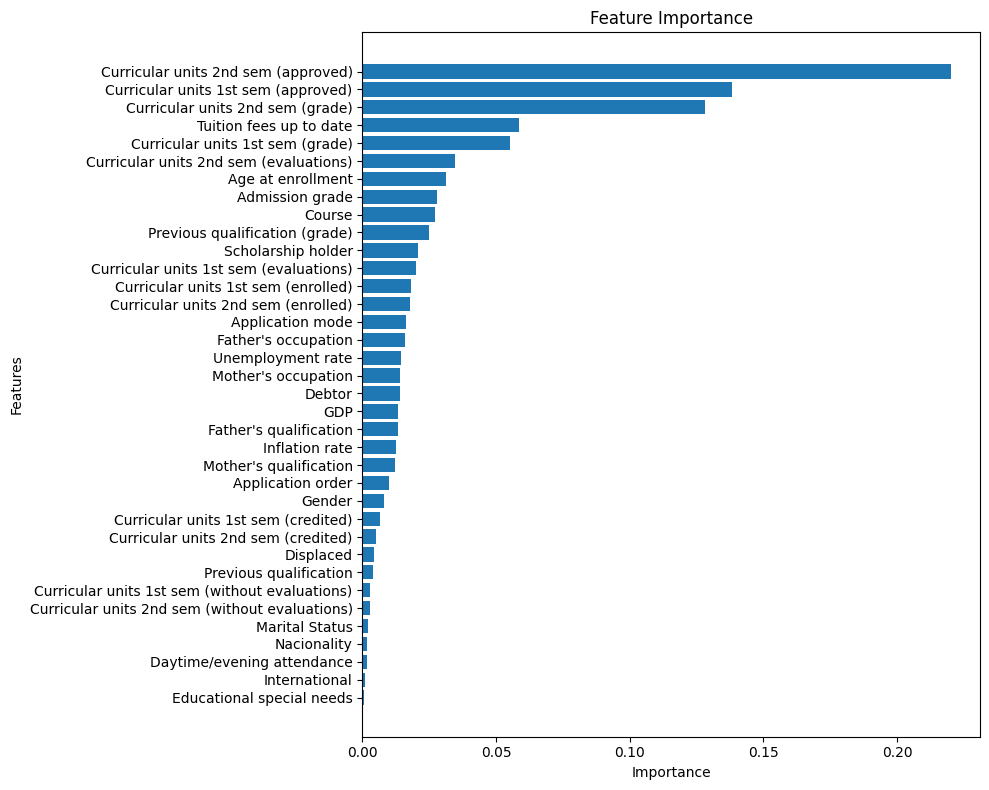

In [275]:
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_
features = X.columns

# Sort by importance (highest to lowest)
sorted_indices = importance.argsort()[::-1]
sorted_features = features[sorted_indices]
sorted_importance = importance[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [276]:
# Get the top 10 important features from the dropout and graduate dataset
top_10_features = sorted_features[:10]
top_10_features


Index(['Curricular units 2nd sem (approved)',
       'Curricular units 1st sem (approved)',
       'Curricular units 2nd sem (grade)', 'Tuition fees up to date',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (evaluations)', 'Age at enrollment',
       'Admission grade', 'Course', 'Previous qualification (grade)'],
      dtype='object')

In [277]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

X = dropout_graduate_data.drop(columns=["target"])
y = dropout_graduate_data["target"]

model = RandomForestClassifier()
rfe = RFE(model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)
print(rfe.support_)  # Selected features
print(rfe.ranking_)  # Feature rankings

[False False False  True False False  True False False False False False
  True False False False  True False False  True False False False False
  True  True False False False  True  True  True False False False False]
[23  8 15  1 25 20  1 24 14 12  6  5  1 19 27 10  1 16 11  1 26 17  7  2
  1  1 22 18  3  1  1  1 21  9 13  4]


In [278]:
# Lis t of selected feature names
selected_features = X.columns[rfe.support_]
selected_features

Index(['Course', 'Previous qualification (grade)', 'Admission grade',
       'Tuition fees up to date', 'Age at enrollment',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'],
      dtype='object')

In [279]:
# Compare selected features with top 10 important features from Random Forest
set(selected_features) == set(top_10_features)


True

In [280]:
# Modify the dropout_graduate_data to only include the top 10 important features and the target column
dropout_graduate_data = dropout_graduate_data[top_10_features.tolist() + ['target']]
dropout_graduate_data.head()

,Curricular units 2nd sem (approved),Curricular units 1st sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Curricular units 1st sem (grade),Curricular units 2nd sem (evaluations),Age at enrollment,Admission grade,Course,Previous qualification (grade),target
0,0,0,0.000000,1,0.000000,0,20,127.3,171,122.0,0
1,6,6,13.666667,0,14.000000,6,19,142.5,9254,160.0,1
2,0,0,0.000000,0,0.000000,0,19,124.8,9070,122.0,0
3,5,6,12.400000,1,13.428571,10,20,119.6,9773,122.0,1
4,6,5,13.000000,1,12.333333,6,45,141.5,8014,100.0,1


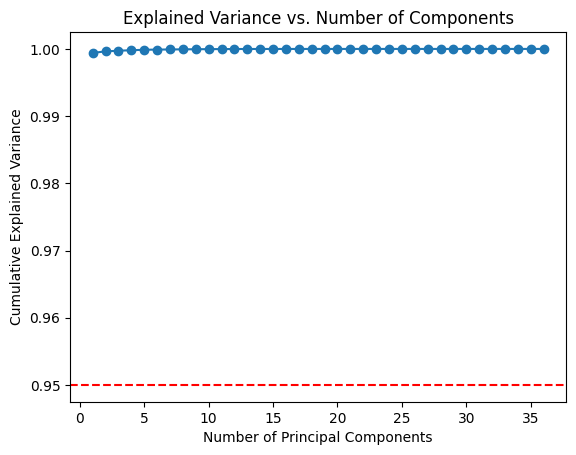

In [281]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA()
pca.fit(X)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')  # 95% threshold
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

In [282]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(pca.explained_variance_ratio_)

[9.99404687e-01 2.31778970e-04]


In [283]:
# Transform X_pca to a DataFrame for better visualization
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df.head()

,PC1,PC2
0,-8682.997691,-1.569626
1,399.977946,-13.901670
2,215.995702,-0.006357
3,919.041905,-6.805610
4,-839.946542,1.884351


In [284]:
# Include the target column for visualization
X_pca_df['target'] = dropout_graduate_data['target'].values
X_pca_df.head()


,PC1,PC2,target
0,-8682.997691,-1.569626,0
1,399.977946,-13.901670,1
2,215.995702,-0.006357,0
3,919.041905,-6.805610,1
4,-839.946542,1.884351,1


##### Step 4: Model Implementation  

In [285]:
# Split X_pca and y for modeling
X_final = X_pca_df[['PC1', 'PC2']]
y_final = X_pca_df['target']

# Use 80-20 train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

evaluation_metrics = []

In [286]:
# Train a Logistic Regression model and evaluate its performance
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics.append({
    "model": "Logistic Regression",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
})

[[205  72]
 [ 23 426]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81       277
           1       0.86      0.95      0.90       449

    accuracy                           0.87       726
   macro avg       0.88      0.84      0.86       726
weighted avg       0.87      0.87      0.87       726



c:\Users\OOSA_Jomar\Documents\AIM\AIM-AI-ML-Capstone-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [287]:
# Train a Decision Tree model and evaluate its performance
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics.append({
    "model": "Decision Tree",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
})

[[220  57]
 [ 53 396]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       277
           1       0.87      0.88      0.88       449

    accuracy                           0.85       726
   macro avg       0.84      0.84      0.84       726
weighted avg       0.85      0.85      0.85       726



In [288]:
# Train Random Forest model and evaluate its performance
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics.append({
    "model": "Random Forest",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
})


[[225  52]
 [ 26 423]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       277
           1       0.89      0.94      0.92       449

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



In [289]:
# train XGBoost model and evaluate its performance
from xgboost import XGBClassifier
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

evaluation_metrics.append({
    "model": "XGBoost",
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
})

[[233  44]
 [ 28 421]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       277
           1       0.91      0.94      0.92       449

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



                 Model  0_Precision  0_Recall  0_F1-Score  1_Precision  \
0  Logistic Regression     0.899123  0.740072    0.811881     0.855422   
1        Decision Tree     0.805861  0.794224    0.800000     0.874172   
2        Random Forest     0.896414  0.812274    0.852273     0.890526   
3              XGBoost     0.892720  0.841155    0.866171     0.905376   

   1_Recall  1_F1-Score  Weighted_Precision  Weighted_Recall  \
0  0.948775    0.899683            0.872096         0.869146   
1  0.881960    0.878049            0.848108         0.848485   
2  0.942094    0.915584            0.892773         0.892562   
3  0.937639    0.921225            0.900548         0.900826   

   Weighted_F1-Score  
0           0.866183  
1           0.848270  
2           0.891428  
3           0.900220  


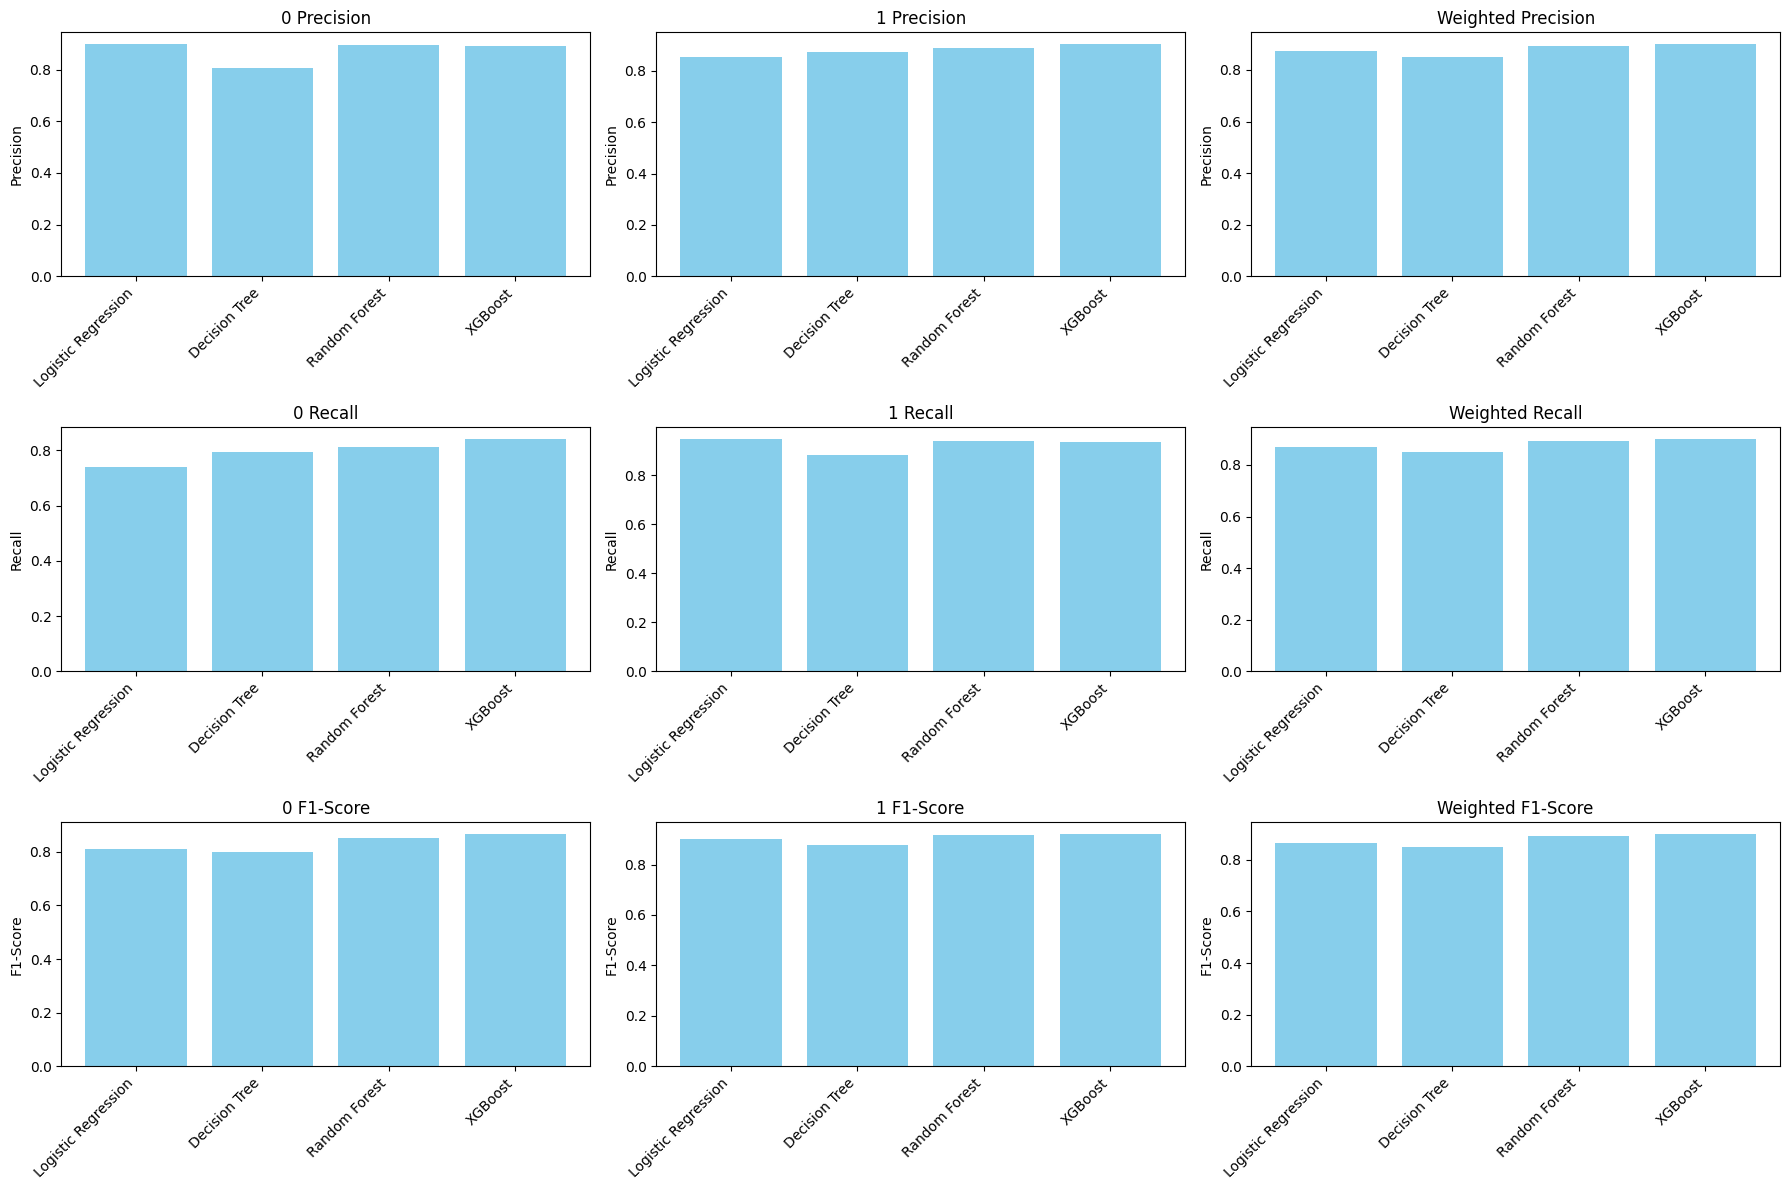

In [290]:
import pandas as pd

import matplotlib.pyplot as plt

# Create a summary table for evaluation metrics
# Create a summary table for evaluation metrics
summary_table = pd.DataFrame({
    "Model": [metrics["model"] for metrics in evaluation_metrics],
    "0_Precision": [metrics["classification_report"]["0"]["precision"] for metrics in evaluation_metrics],
    "0_Recall": [metrics["classification_report"]["0"]["recall"] for metrics in evaluation_metrics],
    "0_F1-Score": [metrics["classification_report"]["0"]["f1-score"] for metrics in evaluation_metrics],
    "1_Precision": [metrics["classification_report"]["1"]["precision"] for metrics in evaluation_metrics],
    "1_Recall": [metrics["classification_report"]["1"]["recall"] for metrics in evaluation_metrics],
    "1_F1-Score": [metrics["classification_report"]["1"]["f1-score"] for metrics in evaluation_metrics],
    "Weighted_Precision": [metrics["classification_report"]["weighted avg"]["precision"] for metrics in evaluation_metrics],
    "Weighted_Recall": [metrics["classification_report"]["weighted avg"]["recall"] for metrics in evaluation_metrics],
    "Weighted_F1-Score": [metrics["classification_report"]["weighted avg"]["f1-score"] for metrics in evaluation_metrics]
})

# Display the summary table
print(summary_table)

# Plot bar charts for precision, recall, and F1-score for each class (0, 1, and weighted avg)
metrics_to_plot = ["Precision", "Recall", "F1-Score"]
classes = ["0", "1", "Weighted"]

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics_to_plot, 1):
    for j, cls in enumerate(classes):
        plt.subplot(3, 3, (i - 1) * 3 + j + 1)
        plt.bar(summary_table["Model"], summary_table[f"{cls}_{metric}"], color='skyblue')
        plt.title(f"{cls} {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()



